# BioJEPA v0.6 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
from pathlib import Path

from biojepa_v0_6 import BioJepa, BioJepaConfig
from dataloader_v0_6 import PretrainLoader, AlignmentLoader, TrainingLoader
from training_v0_6 import create_model, load_feature_banks, run_pretraining, run_alignment, run_full_training, train_linear_decoder
from config_v0_6 import PretrainConfig, AlignmentConfig, FullTrainingConfig, DataConfig
from evals.evals import EvalContext, run_pretraining_evals, run_full_model_evals, save_report

## Device & Paths

In [2]:
def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)
        device = 'cuda'
    print(f'using {device}')
    return device

torch.manual_seed(1337)
random.seed(1337)
torch.set_float32_matmul_precision('high')

device = get_device()

data_cfg = DataConfig(
    data_root=Path('/Users/djemec/data/jepa/v0_4'),
    checkpoint_dir=Path('/Users/djemec/data/jepa/v0_6/checkpoints'),
    input_bank_path=Path('/Users/djemec/data/jepa/v0_4/pert_embd/input_embeddings_dna.npy'),
    anchor_bank_path=Path('/Users/djemec/data/jepa/v0_4/pert_embd/action_embeddings_esm2.npy')
)

using cpu


## Hyperparameters

In [3]:

# Model architecture
model_cfg = BioJepaConfig(
    num_genes=5000,
    n_layer=2,
    heads=2,
    embed_dim=8,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.6,
    gaussian_scale=2.0,
    film_linear_multiple=1.0,
    sim_coeff=25.0,
    std_coeff=25.0,
    cov_coeff=1.0,
    pert_latent_dim=320,
    pert_mode_dim=64
)

# Training configs
pt_cfg = PretrainConfig(epochs=1,lr=1e-3,batch_size=32)
align_cfg = AlignmentConfig(epochs=100,lr=4e-3,batch_size=32)
full_cfg = FullTrainingConfig(epochs=1,predictor_lr=1e-3,composer_lr=1e-4,batch_size=32)

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
input_bank, anchor_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Banks Loaded. Input(DNA): torch.Size([1250, 1536]), Anchor(Prot): torch.Size([1087, 320])
Student/Teacher: 42,002
ACpredictor: 45,168
PerturbationComposer: 882,880


## Pretraining

In [ ]:
pt_train_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pretraining', 
    device=device, total_samples=112373)
pt_val_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pretraining', 
    device=device, total_samples=11044)

pt_results = run_pretraining(model, pt_train_loader, pt_val_loader, pt_cfg, device, data_cfg.checkpoint_dir, model_cfg)


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Pretraining Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
del pt_train_loader
del pt_val_loader
gc.collect()
torch.cuda.empty_cache()

### Pretraining Evals

In [ ]:
eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, config={'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim})
pt_eval_results = run_pretraining_evals(eval_ctx)

save_report(pt_eval_results, data_cfg.checkpoint_dir / 'pretraining_eval_report.json')
pt_eval_results

### Load pretraining model from checkpoint (for resuming)

In [5]:
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_6_pt_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path)

keys = model.load_state_dict(checkpoint['model'])
keys

<All keys matched successfully>

## Stage 2: Perturbation Alignment

In [6]:
align_train_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250)
align_val_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

align_results = run_alignment(model, align_train_loader, align_val_loader, input_bank, anchor_bank, align_cfg, device, data_cfg.checkpoint_dir)


found 1 shards for split train
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pairs_cripri_train.npz
found 1 shards for split val
loading /Users/djemec/data/jepa/v0_4/pert_embd/val/pert_pairs_cripri_val.npz
Alignment: 1250 samples, 39 steps/epoch, 3900 total steps
loading /Users/djemec/data/jepa/v0_4/pert_embd/val/pert_pairs_cripri_val.npz
loading /Users/djemec/data/jepa/v0_4/pert_embd/val/pert_pairs_cripri_val.npz
Step 0 | val loss: 3.4658
Step 0 | Loss: 3.46575 | LR: 1.60e-04
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pairs_cripri_train.npz
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pairs_cripri_train.npz
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pairs_cripri_train.npz
Step 100 | Loss: 3.34585 | LR: 2.20e-03
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pairs_cripri_train.npz
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pairs_cripri_train.npz
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pai

In [7]:
del align_train_loader
del align_val_loader
gc.collect()
torch.cuda.empty_cache()

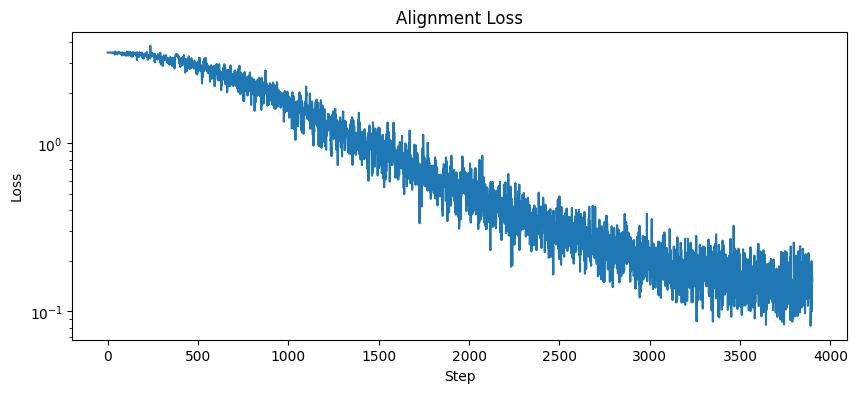

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Alignment Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Stage 3: Full Training

In [ ]:
train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, total_samples=101682)
val_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'training', 
    device=device, total_samples=11044)

full_results = run_full_training(model, train_loader, val_loader, input_bank, full_cfg, device, data_cfg.checkpoint_dir)

found 11 shards for split train
loading /Users/djemec/data/jepa/v0_4/training/train/shard_k562e_train_0000.npz
found 2 shards for split val
loading /Users/djemec/data/jepa/v0_4/training/val/shard_k562e_val_0001.npz
Full training: 101682 samples, 3177 steps/epoch, 3177 total steps
Step 0 | val loss: 58.5166
Step 0 | Loss: 55.24887 | LR: 4.01e-05
Step 25 | Loss: 51.95734 | LR: 1.03e-04
Step 50 | Loss: 44.74072 | LR: 2.67e-04
Step 75 | Loss: 40.29824 | LR: 4.92e-04
Step 100 | val loss: 36.5736
Step 100 | Loss: 36.36256 | LR: 7.24e-04
Step 125 | Loss: 32.69196 | LR: 9.07e-04
Step 150 | Loss: 28.61024 | LR: 9.96e-04
Step 175 | Loss: 26.07169 | LR: 1.00e-03
Step 200 | val loss: 24.5363
Step 200 | Loss: 24.53352 | LR: 9.99e-04
Step 225 | Loss: 22.50510 | LR: 9.99e-04
Step 250 | Loss: 20.71702 | LR: 9.98e-04
Step 275 | Loss: 19.56693 | LR: 9.96e-04
loading /Users/djemec/data/jepa/v0_4/training/val/shard_k562e_val_0000.npz
Step 300 | val loss: 18.3251
Step 300 | Loss: 18.36275 | LR: 9.94e-04
lo

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('Full Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [ ]:
decoder_train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, 
    total_samples=101682)

decoder = train_linear_decoder(model, decoder_train_loader, model_cfg, device, data_cfg.checkpoint_dir)

In [ ]:
del decoder_train_loader
gc.collect()
torch.cuda.empty_cache()

## Full Model Evals

In [ ]:
eval_ctx = EvalContext.from_trained_model(model, decoder=decoder, data_root=data_cfg.data_root, config={'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim})
full_eval_results = run_full_model_evals(eval_ctx)

save_report(full_eval_results, data_cfg.checkpoint_dir / 'full_model_eval_report.json')
full_eval_results

In [ ]:
# Summary
print('=== Training Complete ===')
print(f'Pretraining final loss: {pt_results["final_loss"]:.5f}')
print(f'Alignment final loss: {align_results["final_loss"]:.5f}')
print(f'Full training final loss: {full_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.checkpoint_dir}')